# Taller de Aprendizaje No Supervisado
## Parte 2: Segmentación de Clientes de Tarjeta de Crédito (variables numéricas)

### Credit Card Dataset

[Credit Card Dataset for Clustering](https://www.kaggle.com/datasets/arjunbhasin2013/ccdata)

Resume el comportamiento de uso de unos **9.000 titulares** de tarjeta durante los últimos 6 meses, con **17 variables numéricas de comportamiento** (saldo, compras, adelantos de efectivo, límite de crédito, pagos...).

> **Diferencia clave con el dataset de setas:** aquí **no hay etiqueta**. El objetivo *es* encontrar segmentos de clientes para definir una estrategia de marketing. Esto es aprendizaje no supervisado «de verdad»: no podemos calcular ARI porque no hay verdad de referencia; nos guiamos por métricas internas y por la **interpretabilidad** de los segmentos.

Además, al ser numérico y con escalas muy distintas, aparecen dos pasos que con las setas no hicieron falta: **imputar nulos** y **escalar**.

In [3]:
%matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest
from sklearn.mixture import GaussianMixture
from scipy.cluster.hierarchy import linkage, dendrogram

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

### Leer conjunto de datos y primer vistazo

In [4]:
# Leer el csv (esta en 'data/credit_card.csv') y mostrar las primeras filas.
df = pd.read_csv("data/credit_card.csv")
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


### Exploración de datos

In [5]:
# Tamano del dataset.
df.shape

(8950, 18)

In [6]:
# Descripcion estadistica. Fijaos en las escalas tan distintas entre variables.
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [7]:
# Tipos de datos.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

#### Nulos

In [8]:
# Contar nulos por variable (mostrad solo las que tengan).
nulos = df.isnull().sum()
nulos[nulos > 0]

CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64

Hay nulos en `CREDIT_LIMIT` (1) y `MINIMUM_PAYMENTS` (~313). Al ser variables numéricas muy sesgadas, los imputamos con la **mediana** (más robusta que la media).

In [9]:
# Eliminar CUST_ID (es un identificador)
df = df.drop(columns=["CUST_ID"])
# Imputar los nulos con la mediana de cada columna
df = df.fillna(df.median())

#### Distribución de algunas variables

Muchas variables están **muy sesgadas** (la mayoría de clientes gasta poco y unos pocos muchísimo). Esto es típico en datos financieros.

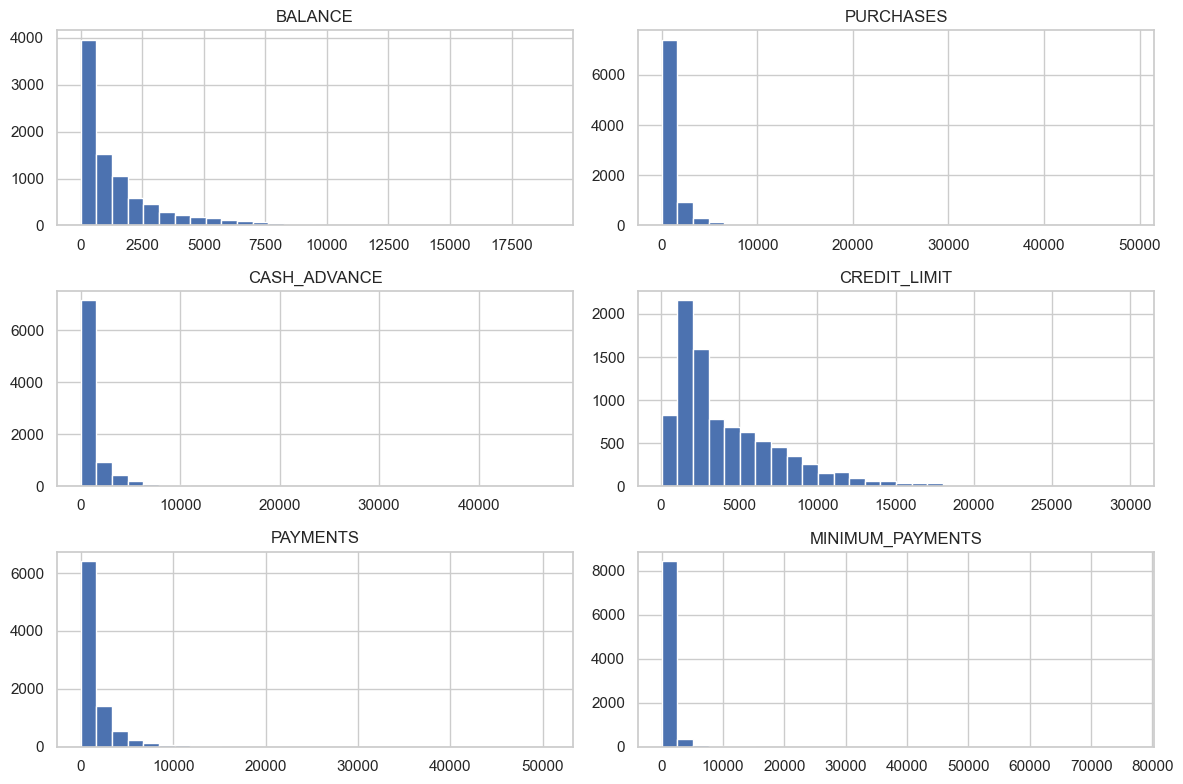

In [10]:
# Pintar histogramas de unas cuantas variables (df[cols].hist...) y observar el sesgo.
cols = ["BALANCE", "PURCHASES", "CASH_ADVANCE", "CREDIT_LIMIT", "PAYMENTS", "MINIMUM_PAYMENTS"]
df[cols].hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()

### Escalado

K-Means, PCA y casi todos los algoritmos de distancia son **sensibles a la escala**. `CREDIT_LIMIT` llega a miles y `PURCHASES_FREQUENCY` está entre 0 y 1: sin escalar, las variables grandes dominarían. Estandarizamos (media 0, desviación 1).

In [11]:
# Aplicar StandardScaler a df -> X (array escalado)
scaler = StandardScaler()
X = scaler.fit_transform(df)
X.shape

(8950, 17)

## PCA

Con 17 variables no podemos pintar un scatter directo. Usamos PCA para (1) ver cuánta información retiene cada componente y (2) proyectar a 2D.

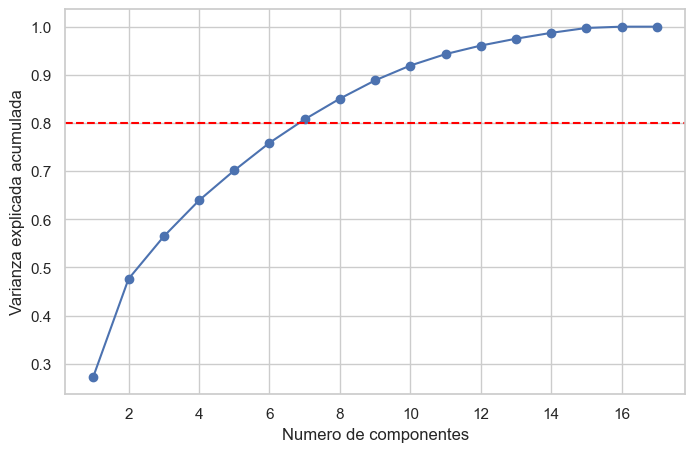

Componentes necesarios para 80% de varianza: 7


In [12]:
# Ajustar PCA sin fijar n_components y mirar explained_variance_ratio_
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X)
# Pintar la varianza explicada acumulada (scree plot)
varianza_acumulada = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker="o")
plt.axhline(0.8, color="red", linestyle="--")
plt.xlabel("Numero de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.show()
# Decidir cuantas componentes hacen falta para ~80% de varianza
for i, valor in enumerate(varianza_acumulada):
    if valor >= 0.8:
        print("Componentes necesarios para 80% de varianza:", i + 1)
        break

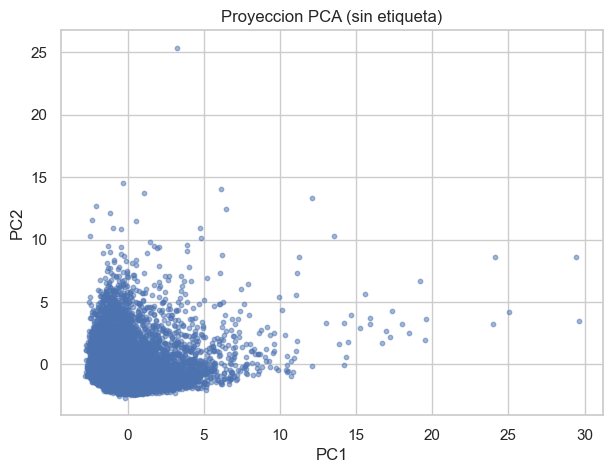

In [13]:
# Proyectar X a 2 componentes y pintar el scatter (aun sin colores: no hay etiqueta)
pca_2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca_2.fit_transform(X)

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=10, alpha=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Proyeccion PCA (sin etiqueta)")
plt.show()

A diferencia de las setas, aquí no vemos grupos separados a simple vista: es más bien una **nube continua**. El clustering nos ayudará a trazar fronteras útiles dentro de ella.

## Clustering: ¿cuántos segmentos? Codo + Silhouette

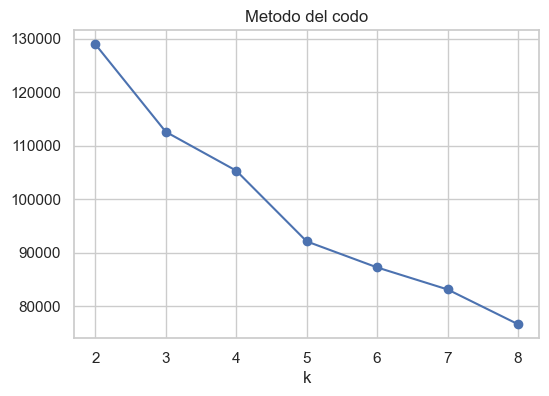

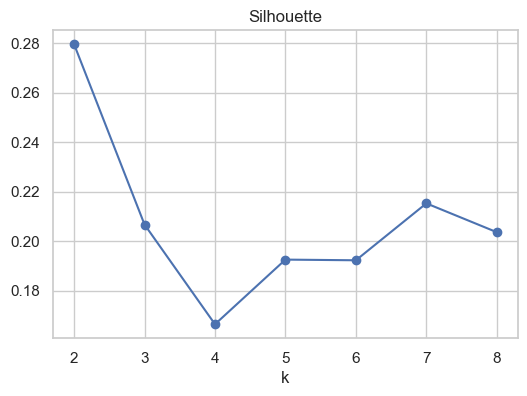

Mejor k: 2


In [14]:
k_values = range(2, 9)
inercias, silhouettes = [], []
for k in k_values:
    # Ajustar KMeans y guardar inercia + silhouette    
    modelo = KMeans(n_clusters=k, random_state=RANDOM_STATE)
    etiquetas = modelo.fit_predict(X)

    inercias.append(modelo.inertia_)
    silhouettes.append(silhouette_score(X, etiquetas))

# Pintar las dos curvas y elegir best_k (el de mayor silhouette)
plt.figure(figsize=(6, 4))
plt.plot(list(k_values), inercias, marker="o")
plt.title("Metodo del codo")
plt.xlabel("k")
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(list(k_values), silhouettes, marker="o")
plt.title("Silhouette")
plt.xlabel("k")
plt.show()

# Elegimos el k con mayor silhouette
mejor_posicion = silhouettes.index(max(silhouettes))
best_k = list(k_values)[mejor_posicion]
print("Mejor k:", best_k)

### K-Means final

In [15]:
# Entrenar KMeans con best_k, guardar las etiquetas y mirar el tamano de cada cluster
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE)
cluster_labels = kmeans.fit_predict(X)

pd.Series(cluster_labels).value_counts().sort_index()

0    1860
1    7090
Name: count, dtype: int64

### Comparativa de algoritmos

Sin etiqueta, comparamos con **métricas internas**: *silhouette* y *Calinski-Harabasz* (más alto = mejor) y *Davies-Bouldin* (más bajo = mejor).

In [16]:
# Definir evaluar(nombre, labels, X) con silhouette, davies_bouldin y calinski_harabasz
# (sin ARI: no hay etiqueta). Comparar KMeans, Aglomerativo y GMM.

# Funcion que calcula las metricas internas (no hay etiqueta, asi que no hay ARI)
def evaluar(nombre, labels, X):
    resultado = {}
    resultado["algoritmo"] = nombre
    resultado["silhouette"] = silhouette_score(X, labels)
    resultado["davies_bouldin"] = davies_bouldin_score(X, labels)
    resultado["calinski_harabasz"] = calinski_harabasz_score(X, labels)
    return resultado

lista_resultados = []
lista_resultados.append(evaluar("KMeans", cluster_labels, X))

modelo_agg = AgglomerativeClustering(n_clusters=best_k)
etiquetas_agg = modelo_agg.fit_predict(X)
lista_resultados.append(evaluar("Aglomerativo", etiquetas_agg, X))

modelo_gmm = GaussianMixture(n_components=best_k, random_state=RANDOM_STATE)
etiquetas_gmm = modelo_gmm.fit_predict(X)
lista_resultados.append(evaluar("GMM", etiquetas_gmm, X))

tabla = pd.DataFrame(lista_resultados)
tabla

,algoritmo,silhouette,davies_bouldin,calinski_harabasz
0,KMeans,0.279540,1.800894,1609.609316
1,Aglomerativo,0.192103,2.030029,1393.530604
2,GMM,0.196247,2.373828,1184.571048


### Dendrograma

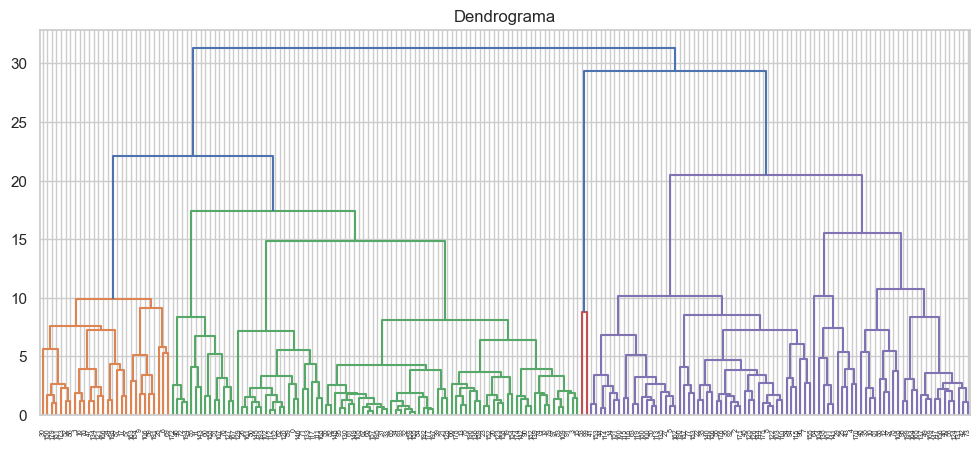

In [17]:
# linkage + dendrogram sobre una muestra de X

# Tomamos una muestra de 200 filas
np.random.seed(RANDOM_STATE)
indices_muestra = np.random.choice(len(X), size=200, replace=False)
X_muestra = X[indices_muestra]

# Calculamos el linkage
Z = linkage(X_muestra, method="ward")

# Pintamos el dendrograma
plt.figure(figsize=(12, 5))
dendrogram(Z)
plt.title("Dendrograma")
plt.show()

### DBSCAN: ¿hay clusters de densidad aquí?

Probamos DBSCAN. Veréis que en alta dimensión tiende a juntar casi todo en **un solo cluster** y marcar el resto como **ruido**. Eso nos dice algo importante: estos datos son una nube continua, no grupos separados por densidad. Aquí DBSCAN funciona mejor como **detector de atípicos** que como segmentador.

Clusters encontrados: 4
Puntos de ruido: 239 de 8950


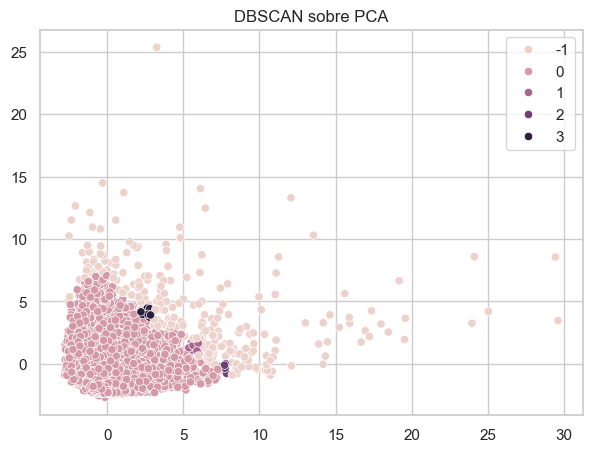

In [18]:
# Ejecutar DBSCAN sobre la proyeccion PCA(2). Observar cuantos clusters y cuanto ruido.
modelo_db = DBSCAN(eps=0.5, min_samples=10)
etiquetas_db = modelo_db.fit_predict(X_pca)

num_clusters = len(set(etiquetas_db)) - (1 if -1 in etiquetas_db else 0)
num_ruido = list(etiquetas_db).count(-1)

print("Clusters encontrados:", num_clusters)
print("Puntos de ruido:", num_ruido, "de", len(etiquetas_db))

plt.figure(figsize=(7, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=etiquetas_db)
plt.title("DBSCAN sobre PCA")
plt.show()

### Visualización de los segmentos (t-SNE)

Proyectamos con t-SNE (sobre una muestra) y coloreamos por el segmento de K-Means.

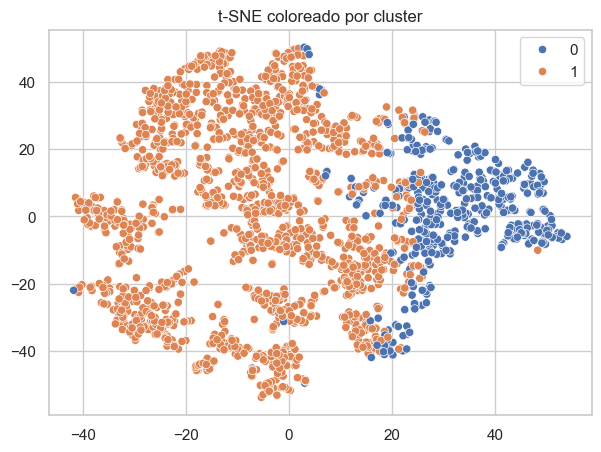

In [19]:
# t-SNE sobre una muestra de X, coloreado por el cluster de KMeans

# Tomamos una muestra de 2000 filas
np.random.seed(RANDOM_STATE)
indices_muestra2 = np.random.choice(len(X), size=2000, replace=False)
X_muestra = X[indices_muestra2]
etiquetas_muestra = cluster_labels[indices_muestra2]

# Calculamos t-SNE
tsne = TSNE(n_components=2, random_state=RANDOM_STATE)
X_tsne = tsne.fit_transform(X_muestra)

# Lo pintamos coloreado por el cluster de KMeans
plt.figure(figsize=(7, 5))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=etiquetas_muestra)
plt.title("t-SNE coloreado por cluster")
plt.show()

## Interpretación de los segmentos

Lo más importante en segmentación: **¿qué caracteriza a cada grupo?** Calculamos la media de cada variable por cluster y la estandarizamos entre clusters (rojo = por encima de la media, azul = por debajo). Así leemos el «perfil» de cada segmento.

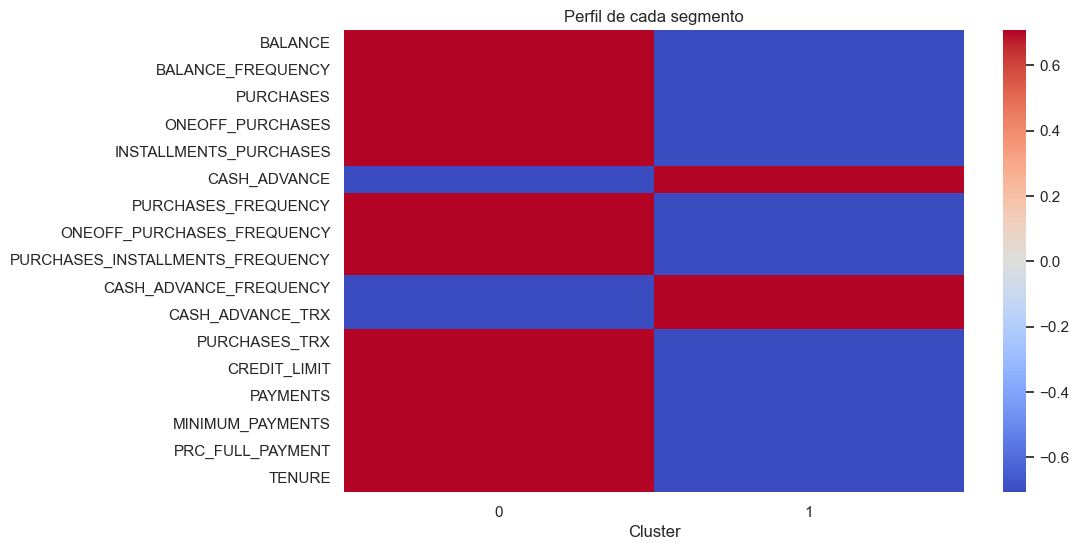

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
cluster,,,,,,,,,,,,,,,,,
0,2147.310087,0.979774,3364.893645,2075.077145,1290.139081,761.443235,0.937914,0.588182,0.712940,0.082253,2.232258,46.131183,7182.543988,3595.423358,1195.056462,0.285596,11.891935
1,1411.573053,0.850380,383.636260,203.479687,180.450879,1035.911430,0.372936,0.101266,0.273011,0.149020,3.515515,6.466714,3789.040383,1244.590977,753.048031,0.119117,11.419041


In [20]:
# Anadir la columna 'cluster' al df original (sin escalar)
df_clusters = df.copy()
df_clusters["cluster"] = cluster_labels

# Calcular la media de cada variable por cluster
perfil = df_clusters.groupby("cluster").mean()

# Estandarizar entre clusters y pintar un heatmap (perfil de cada segmento)
perfil_z = (perfil - perfil.mean()) / perfil.std()

plt.figure(figsize=(10, 6))
sns.heatmap(perfil_z.T, cmap="coolwarm", center=0)
plt.title("Perfil de cada segmento")
plt.xlabel("Cluster")
plt.show()

perfil

Leyendo el heatmap se pueden nombrar los segmentos en términos de **negocio**, por ejemplo: clientes de alto saldo y muchas compras (VIP), clientes que tiran de adelantos de efectivo (riesgo), clientes poco activos, etc. Ese nombre y la estrategia asociada es justo el entregable que pide el caso.

## Detección de anomalías (Isolation Forest)

Identificamos los clientes con comportamiento más atípico (posible fraude, errores de datos o clientes premium fuera de norma).

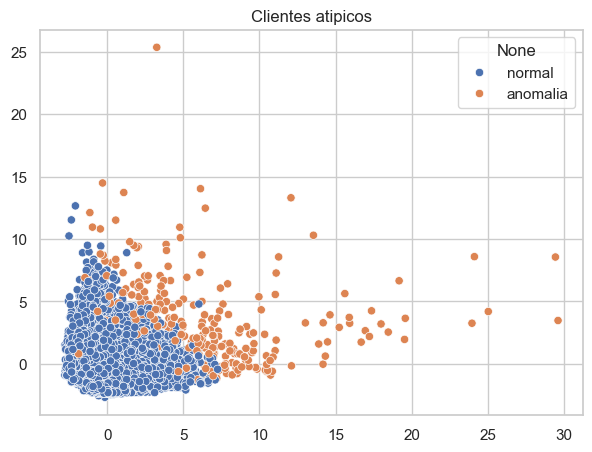

Numero de clientes atipicos: 269


In [21]:
# IsolationForest sobre X, marcar los atipicos (-1) y pintarlos sobre PCA(2)

# Definimos el modelo: esperamos un 3% de clientes atipicos
iso = IsolationForest(contamination=0.03, random_state=RANDOM_STATE)

# Lo entrenamos y predecimos: -1 es anomalia
anomaly_labels = iso.fit_predict(X)

# Lo pintamos sobre la proyeccion PCA
plt.figure(figsize=(7, 5))
colores = pd.Series(anomaly_labels).map({1: "normal", -1: "anomalia"})
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=colores)
plt.title("Clientes atipicos")
plt.show()

print("Numero de clientes atipicos:", list(anomaly_labels).count(-1))


---
## Para ir más allá (opcional)

- **Ingeniería de KPIs**: derivar variables como *ratio de uso del límite* (`BALANCE / CREDIT_LIMIT`) o *compra media por transacción* suele mejorar mucho los segmentos.
- **UMAP / HDBSCAN** para visualización y clustering por densidad más robusto.
- **Transformación logarítmica** de las variables sesgadas antes de escalar.

c:\Users\Usuario\Desktop\bootcamp-da-p2\project08_DA-project-classification_Grupo4\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


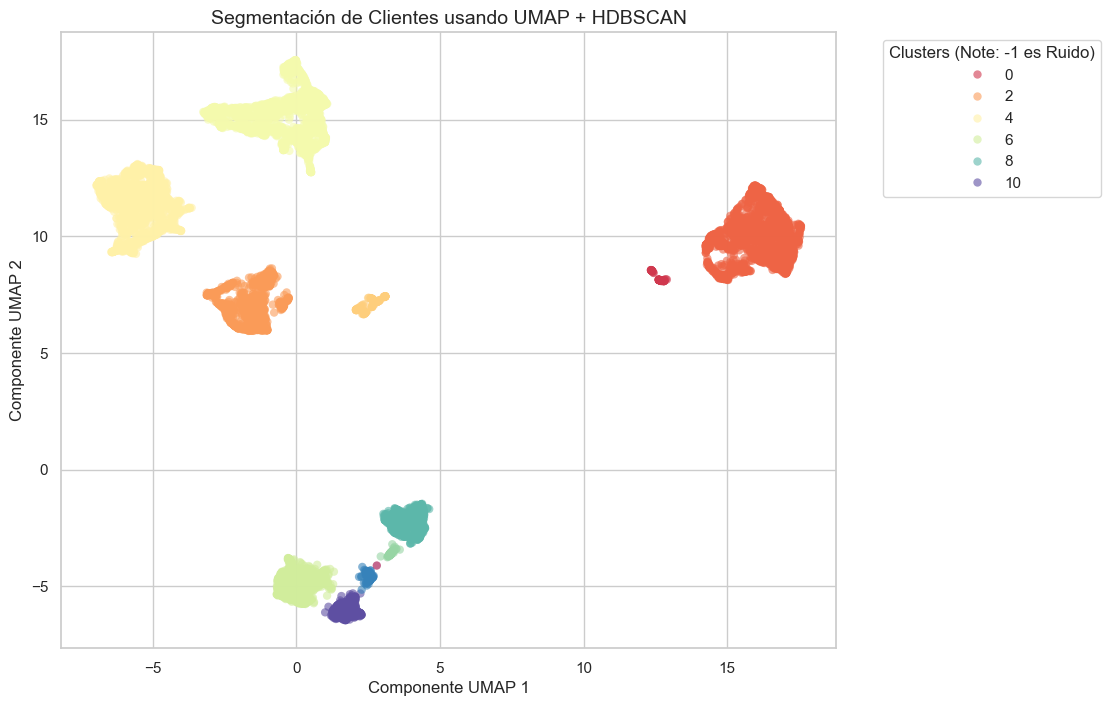

Distribución de clientes por segmento:
Cluster
 1     1980
 5     1803
 4     1652
 2     1050
 6      931
 8      707
 10     393
 3      165
 9      112
 7       82
 0       74
-1        1
Name: count, dtype: int64


In [22]:

# INGENIERÍA DE KPIs

df_advanced = df.copy()

# Evitamos divisiones por cero sumando un pequeño épsilon (1e-5)
df_advanced['LIMIT_USAGE'] = df_advanced['BALANCE'] / (df_advanced['CREDIT_LIMIT'] + 1e-5)
df_advanced['AVG_PURCHASE_AMT'] = df_advanced['PURCHASES'] / (df_advanced['PURCHASES_TRX'] + 1e-5)
df_advanced['CASH_ADVANCE_AMT_PER_TRX'] = df_advanced['CASH_ADVANCE'] / (df_advanced['CASH_ADVANCE_TRX'] + 1e-5)

# TRANSFORMACIÓN LOGARÍTMICA Y ESCALADO

# Aplicamos log(x + 1) debido a la gran cantidad de valores en cero
df_log = np.log1p(df_advanced)

# Escalado estándar de las variables transformadas
scaler_adv = StandardScaler()
df_scaled_adv = scaler_adv.fit_transform(df_log)


# REDUCCIÓN DE DIMENSIONALIDAD CON UMAP

import umap

# Reducimos a 2 dimensiones para facilitar la densidad y visualización
reducer = umap.UMAP(n_neighbors=30, min_dist=0.0, n_components=2, random_state=RANDOM_STATE)
embedding = reducer.fit_transform(df_scaled_adv)

# CLUSTERING BASADO EN DENSIDAD CON HDBSCAN

import hdbscan

clusterer = hdbscan.HDBSCAN(min_cluster_size=60, min_samples=15, gen_min_span_tree=True)
cluster_labels = clusterer.fit_predict(embedding)

# Añadir resultados al dataframe de visualización
df_viz = pd.DataFrame(embedding, columns=['UMAP_1', 'UMAP_2'])
df_viz['Cluster'] = cluster_labels


# VISUALIZACIÓN DE LOS SEGMENTOS DETECTADOS

plt.figure(figsize=(10, 8))
# El cluster -1 representa "ruido" u outliers según HDBSCAN
sns.scatterplot(
    x='UMAP_1', y='UMAP_2', 
    hue='Cluster', 
    palette='Spectral', 
    data=df_viz, 
    alpha=0.6, 
    linewidth=0
)
plt.title('Segmentación de Clientes usando UMAP + HDBSCAN', fontsize=14)
plt.xlabel('Componente UMAP 1')
plt.ylabel('Componente UMAP 2')
plt.legend(title='Clusters (Note: -1 es Ruido)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Mostrar contador de clientes por cluster obtenido
print("Distribución de clientes por segmento:")
print(df_viz['Cluster'].value_counts())

## Conclusiones

- Sin etiqueta, la segmentación se valida con métricas internas (*silhouette*, etc.) y, sobre todo, con la **interpretabilidad** de los perfiles.
- Imputar y **escalar** fue imprescindible aquí (a diferencia de las setas).
- K-Means, GMM y Aglomerativo dan segmentos coherentes; DBSCAN reveló que los datos son una nube continua (mejor como detector de atípicos).
- El heatmap de perfiles convierte los clusters en **segmentos de negocio accionables**.